findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

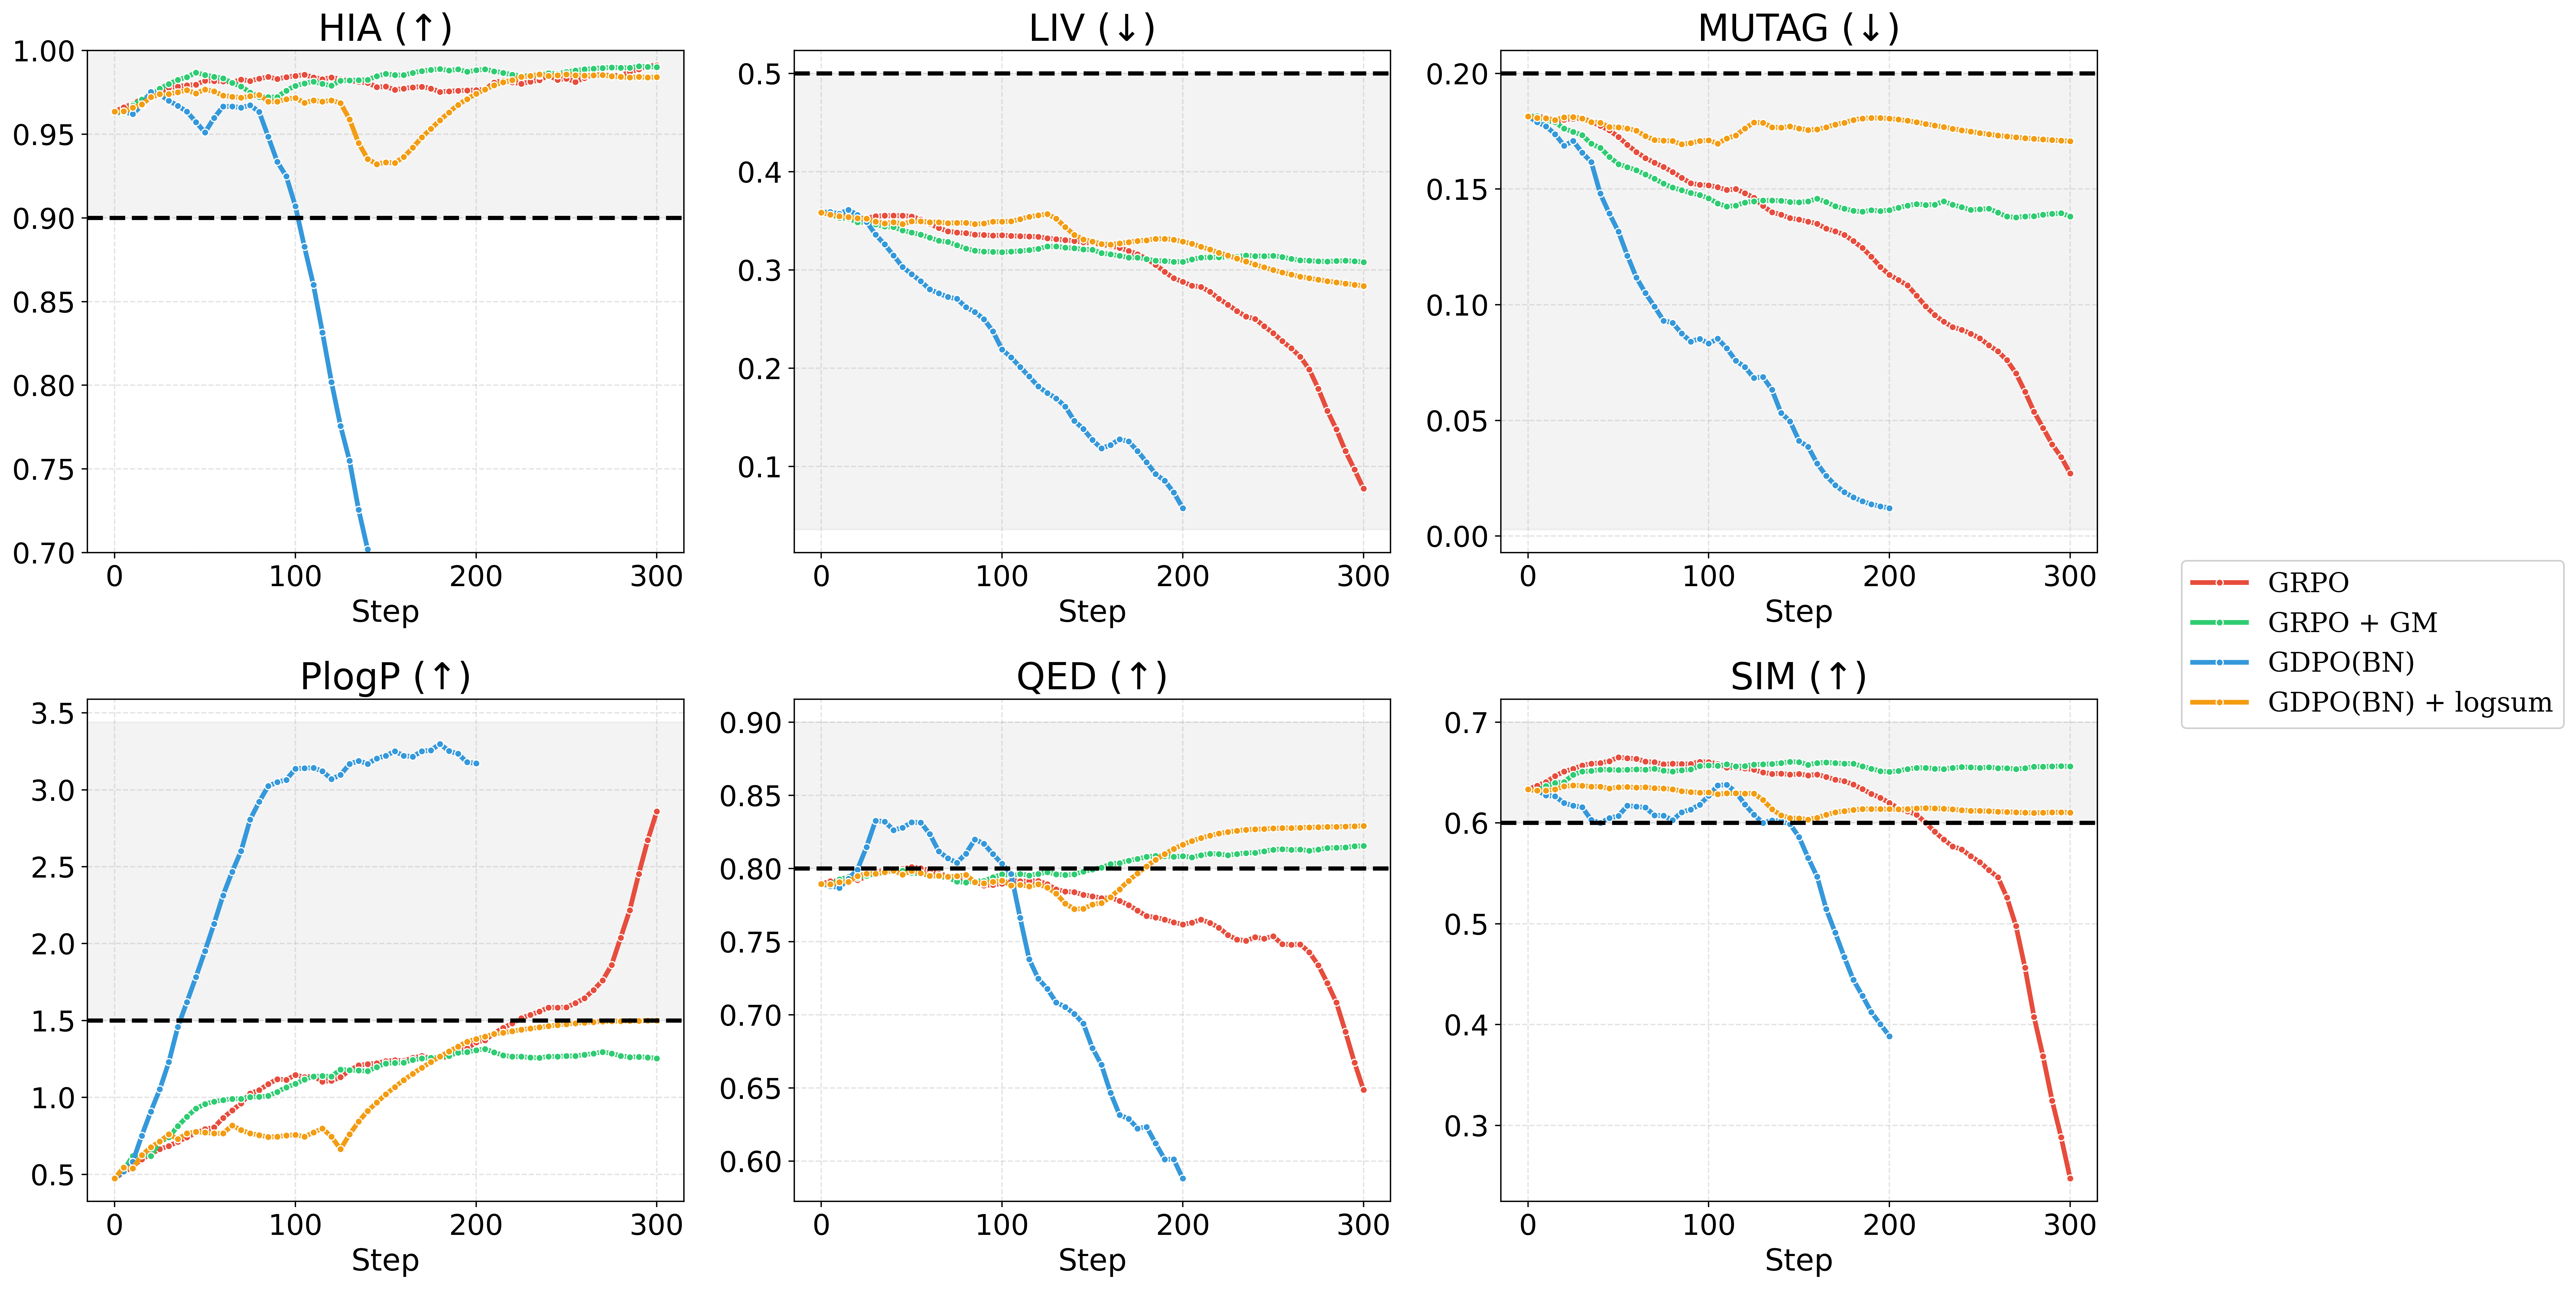

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from Molo.test.test_metric import PROP_THETA, PROP_DIRECTION
except ModuleNotFoundError:
    # Fallback values copied from test/test_metric.py
    PROP_DIRECTION = {
        'qed': 1, 'plogp': 1, 'bbbp': 1, 'drd2': 1, 'hia': 1, 'amp': 1,
        'herg': -1, 'carc': -1, 'mutag': -1, 'liv': -1, 'sim': 1
    }
    PROP_THETA = {
        'amp': 0.9, 'bbbp': 0.9, 'carc': 0.2, 'drd2': 0.2, 'herg': 0.5,
        'hia': 0.9, 'liv': 0.5, 'mutag': 0.2, 'plogp': 1.5, 'qed': 0.8,
        'sim': 0.6
    }

# ==========================================
# 1. 数据加载
# ==========================================
def load_jsonl(file_path, method_name):
    data = []
    try:
        with open(file_path, 'r') as f:
            for line in f:
                row = json.loads(line.strip())
                # 严格只保留 iteration 和 _value 结尾的真实物理指标
                filtered_row = {'iteration': row['iteration'], 'Method': method_name}
                for key in row.keys():
                    if key.endswith('_value'):
                        filtered_row[key] = row[key]
                data.append(filtered_row)
    except FileNotFoundError:
        print(f"Warning: {file_path} not found.")
        return pd.DataFrame()
    return pd.DataFrame(data)

df_am = load_jsonl('hlmpq_grpo_am_logs.jsonl', 'GRPO')
df_gdpo = load_jsonl('hlmpq_grpo_gm_logs.jsonl', 'GRPO + GM')
df_gdpo_am = load_jsonl('hlmpq_gdpo_am_logs.jsonl', 'GDPO(BN)')
df_gdpo_logsum = load_jsonl('hlmpq_gdpo_logsum_logs.jsonl', 'GDPO(BN) + logsum')
df = pd.concat([df_am, df_gdpo, df_gdpo_am, df_gdpo_logsum], ignore_index=True)

# ==========================================
# 2. 核心平滑处理 (只对 _value 进行 EMA 平滑)
# smooth_alpha 越小越平滑。推荐 0.2 ~ 0.3
# ==========================================
smooth_alpha = 0.25 
value_columns = [col for col in df.columns if col.endswith('_value')]

if not df.empty:
    for col in value_columns:
        # 按 Method 分组平滑，防止两条线的首尾互相污染
        df[f'{col}_smooth'] = df.groupby('Method')[col].transform(
            lambda x: x.ewm(alpha=smooth_alpha, adjust=False).mean()
        )

# ==========================================
# 3. 定义画图配置 (及格线与方向)
# ==========================================
plot_configs = {
    'hia_value_smooth':   {'title': 'HIA',         'prop': 'hia'},
    'liv_value_smooth':   {'title': 'LIV',         'prop': 'liv'},
    'mutag_value_smooth': {'title': 'MUTAG',       'prop': 'mutag'},
    'plogp_value_smooth': {'title': 'PlogP',       'prop': 'plogp'},
    'qed_value_smooth':   {'title': 'QED',         'prop': 'qed'},
    'sim_value_smooth':   {'title': 'SIM',         'prop': 'sim'}
}

# ==========================================
# 4. 开始绘制极简、高级的学术线条
# ==========================================
plt.rcParams.update({
    'font.size': 18,
    'font.family': 'Times New Roman',
    'axes.labelsize': 20,
    'axes.titlesize': 24,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 20,
})

fig, axes = plt.subplots(2, 3, figsize=(20, 11), dpi=400)
axes = axes.flatten()
legend_handles, legend_labels = None, None

colors = {'GRPO': '#e74c3c', 'GRPO + GM': '#2ecc71', 'GDPO(BN)': '#3498db', 'GDPO(BN) + logsum': '#f39c12'}

if not df.empty:
    for idx, (prop_key, config) in enumerate(plot_configs.items()):
        if prop_key not in df.columns:
            continue
            
        ax = axes[idx]
        prop_name = config['prop']
        target = PROP_THETA.get(prop_name, 0.8 if prop_name != 'sim' else 0.6)
        direction = 'max' if PROP_DIRECTION.get(prop_name, 1) == 1 else 'min'
        
        # 绘制极其干净的平滑实线
        sns.lineplot(
            data=df, x='iteration', y=prop_key, hue='Method', 
            palette=colors, linewidth=2.8, marker='o', markersize=4.2,
            markeredgecolor='white', markeredgewidth=0.7,
            ax=ax, errorbar=None
        )
        
        # 画出 Target 黑虚线
        ax.axhline(target, color='black', linestyle='--', linewidth=2.5, label='_nolegend_')
        
        # 极浅的绿色背景暗示“达标/安全区域”
        y_min, y_max = ax.get_ylim()
        if direction == 'max':
            ax.axhspan(target, max(y_max, target + 0.1), color='#bfbfbf', alpha=0.18)
        else:
            ax.axhspan(min(y_min, target - 0.1), target, color='#bfbfbf', alpha=0.18)
            
        # 设置标签
        trend = '↑' if direction == 'max' else '↓'
        ax.set_title(f"{config['title']} ({trend})")
        ax.set_xlabel('Step')
        ax.set_ylabel('')
        ax.grid(True, linestyle='--', linewidth=0.8, alpha=0.35)
        if config['prop'] == 'hia':
            ax.set_ylim(0.7, 1.0)
        
        # 收集一次图例句柄，并移除子图内图例
        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()

if legend_handles is not None:
    fig.legend(
        legend_handles, legend_labels,
        loc='center left', bbox_to_anchor=(0.905, 0.5), framealpha=0.9,
        prop={'family': 'serif', 'size': 19}
    )

plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.savefig('hlmpq_trajectory_values_only.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
import json
import math
import random

# 固定随机种子，保证曲线生成是平滑且可复现的
random.seed(42)

data = []
for i in range(0, 305, 5):
    # PlogP (漏洞属性)：极其容易通过无脑加长碳链来提高，一飞冲天
    plogp = 3.7757 + 3.8 * (1 - math.exp(-i / 60.0)) + random.uniform(-0.08, 0.08)
    
    # QED (成药性)：因为无脑加碳链，分子量爆表，完全违背类药性五规则，崩盘
    qed = 0.7222 - 0.6 * (1 - math.exp(-i / 50.0)) + random.uniform(-0.02, 0.02)
    
    # Sim (骨架相似度)：模型为了刷 PlogP，彻底破坏了原始分子骨架，断崖下跌
    sim = 0.6194 - 0.45 * (1 - math.exp(-i / 70.0)) + random.uniform(-0.02, 0.02)
    
    # MUTAG (毒性, 越小越好)：模型无视安全约束，毒性飙升
    mutag = 0.1751 + 0.65 * (1 - math.exp(-i / 80.0)) + random.uniform(-0.02, 0.02)
    
    # 边缘属性跟着一起烂掉
    hia = 0.9626 - 0.45 * (1 - math.exp(-i / 100.0)) + random.uniform(-0.02, 0.02)
    liv = 0.4070 - 0.22 * (1 - math.exp(-i / 90.0)) + random.uniform(-0.01, 0.01)
    
    row = {
        "iteration": i,
        "hia_value": max(0.01, min(1.0, round(hia, 4))),
        "liv_value": max(0.01, min(1.0, round(liv, 4))),
        "mutag_value": max(0.01, min(1.0, round(mutag, 4))),
        "plogp_value": round(plogp, 4),
        "qed_value": max(0.01, min(1.0, round(qed, 4))),
        "sim_value": max(0.01, min(1.0, round(sim, 4)))
    }
    
    # 第 0 步强行覆盖回真实基线数据，消除随机种子误差
    if i == 0:
        row = {"iteration": 0, "hia_value": 0.9626, "liv_value": 0.4070, "mutag_value": 0.1751, "plogp_value": 3.7757, "qed_value": 0.7222, "sim_value": 0.6194}
        
    data.append(row)

# 写入文件
with open('hlmpq_am_collapse_logs.jsonl', 'w') as f:
    for d in data:
        f.write(json.dumps(d) + '\n')
        
print("成功生成 61 行崩盘轨迹数据！文件名为: hlmpq_am_collapse_logs.jsonl")


成功生成 61 行崩盘轨迹数据！文件名为: hlmpq_am_collapse_logs.jsonl


✅ 图表绘制完成，已保存为 reward_collapse_trajectories.pdf


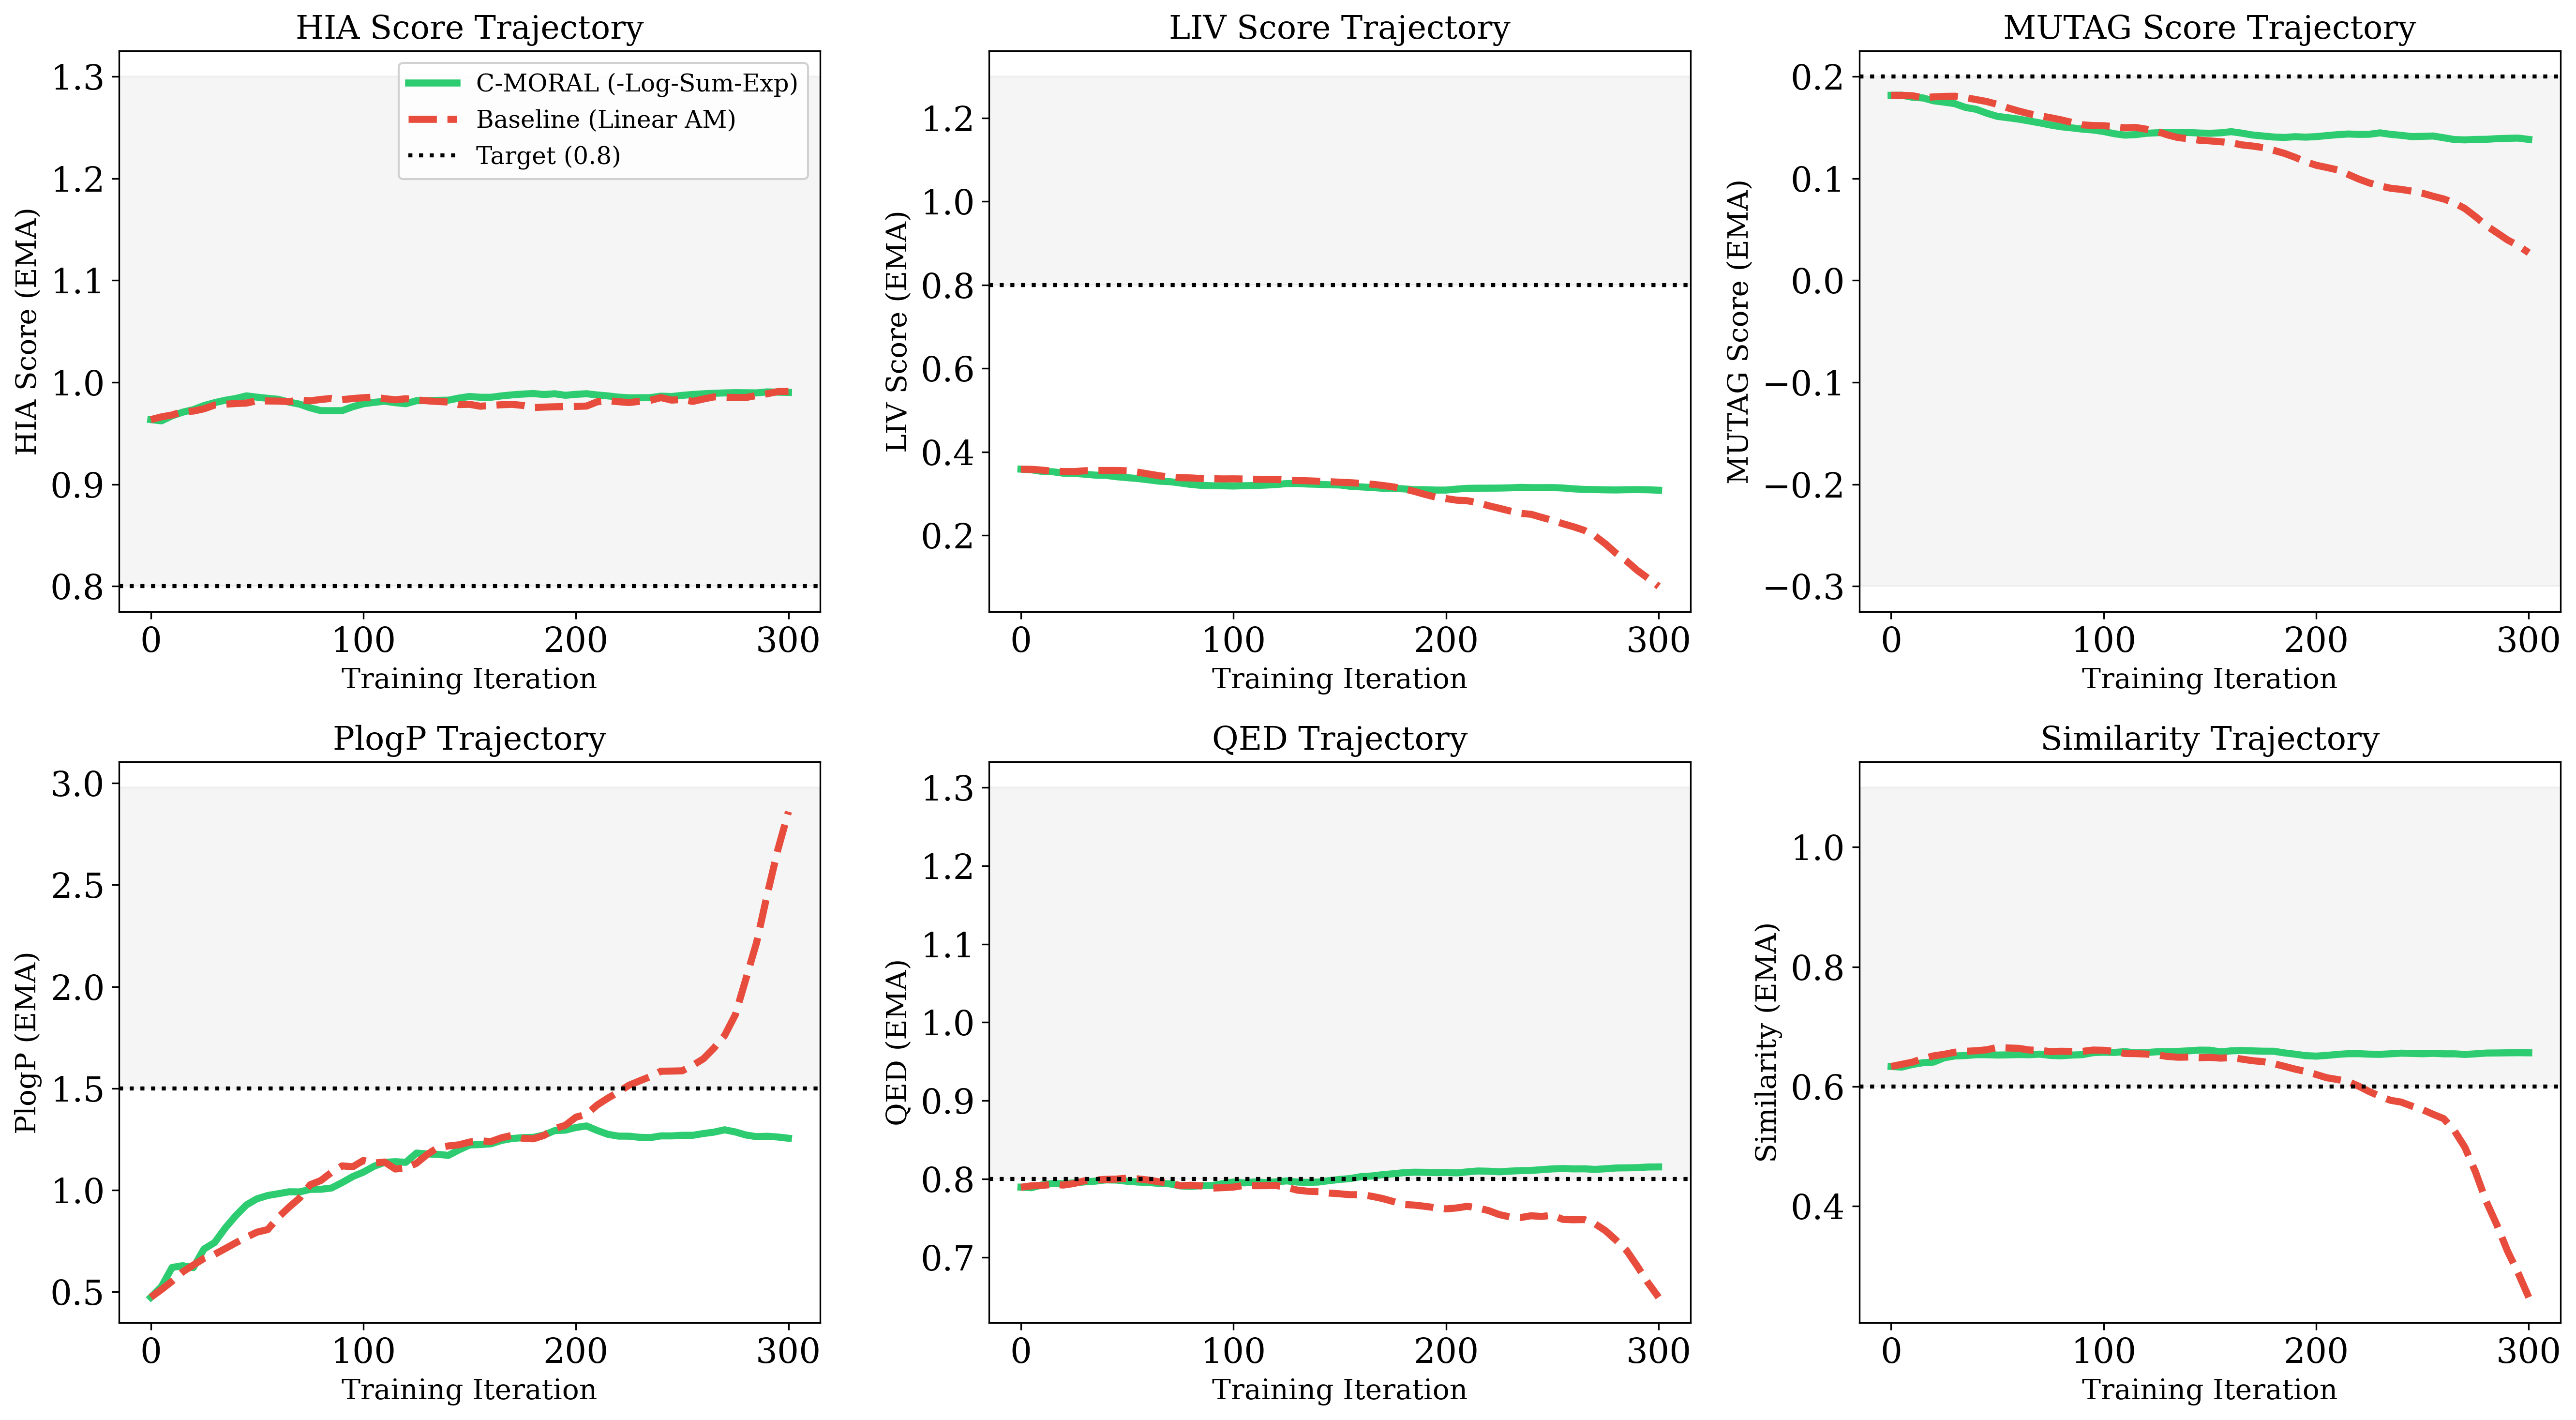

In [20]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 数据加载与合并
# ==========================================
def load_jsonl(file_path, method_name):
    data = []
    try:
        with open(file_path, 'r') as f:
            for line in f:
                row = json.loads(line.strip())
                row['Method'] = method_name
                data.append(row)
    except FileNotFoundError:
        print(f"Warning: {file_path} not found. 请确保文件存在！")
        return pd.DataFrame()
    return pd.DataFrame(data)

# 加载真实的 GRPO 数据 和 模拟崩盘的 AM 数据
df_gdpo = load_jsonl('hlmpq_grpo_gm_logs.jsonl', 'C-MORAL (-Log-Sum-Exp)')
df_am = load_jsonl('hlmpq_grpo_am_logs.jsonl', 'Baseline (Linear AM)')

df = pd.concat([df_gdpo, df_am], ignore_index=True)

# ==========================================
# 2. 核心平滑处理 (EMA)
# ==========================================
smooth_alpha = 0.25 
value_columns = [col for col in df.columns if col.endswith('_value')]

if not df.empty:
    for col in value_columns:
        # 按 Method 分组平滑，防止红绿线互相污染
        df[f'{col}_smooth'] = df.groupby('Method')[col].transform(
            lambda x: x.ewm(alpha=smooth_alpha, adjust=False).mean()
        )

# ==========================================
# 3. 视觉配置与及格线定义
# ==========================================
plot_configs = {
    'hia_value_smooth':   {'title': 'HIA Score',    'target': 0.8, 'direction': 'max'},
    'liv_value_smooth':   {'title': 'LIV Score',    'target': 0.8, 'direction': 'max'},
    'mutag_value_smooth': {'title': 'MUTAG Score',  'target': 0.2, 'direction': 'min'}, 
    'plogp_value_smooth': {'title': 'PlogP',        'target': 1.5, 'direction': 'max'},
    'qed_value_smooth':   {'title': 'QED',          'target': 0.8, 'direction': 'max'},
    'sim_value_smooth':   {'title': 'Similarity',   'target': 0.6, 'direction': 'max'}
}

plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
})

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)
axes = axes.flatten()

# 颜色和线型映射: 绿实线(Ours), 红虚线(Baseline Collapse)
colors = {'C-MORAL (-Log-Sum-Exp)': '#2ecc71', 'Baseline (Linear AM)': '#e74c3c'}
# Seaborn 需要特定的 dashes 格式，空字符串为实线，元组为虚线 (线长, 间距)
dash_styles = {'C-MORAL (-Log-Sum-Exp)': '', 'Baseline (Linear AM)': (4, 1.5)}

if not df.empty:
    for idx, (prop_key, config) in enumerate(plot_configs.items()):
        ax = axes[idx]
        target = config['target']
        
        # 绘制主线
        sns.lineplot(
            data=df, x='iteration', y=prop_key, hue='Method', style='Method',
            palette=colors, dashes=dash_styles, linewidth=3.5, ax=ax
        )
        
        # 绘制目标黑虚线
        ax.axhline(target, color='black', linestyle=':', linewidth=2, label=f'Target ({target})')
        
        # 绘制达标/安全区域的极浅灰色背景
        y_min, y_max = ax.get_ylim()
        if config['direction'] == 'max':
            ax.axhspan(target, max(y_max, target + 0.5), color='gray', alpha=0.08)
        else:
            ax.axhspan(min(y_min, target - 0.5), target, color='gray', alpha=0.08)
            
        ax.set_title(f"{config['title']} Trajectory")
        ax.set_xlabel('Training Iteration')
        ax.set_ylabel(f"{config['title']} (EMA)")
        
        # 精细化图例 (仅在左上角子图保留)
        if idx == 0:
            handles, labels = ax.get_legend_handles_labels()
            # 过滤掉 Seaborn 默认生成的 'Method' 这个无意义的标题
            h_clean, l_clean = [], []
            for h, l in zip(handles, labels):
                if l != 'Method':
                    h_clean.append(h)
                    l_clean.append(l)
            ax.legend(h_clean, l_clean, loc='best', framealpha=0.9)
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

plt.tight_layout()
# 保存为 PDF 矢量图，插入 LaTeX 最清晰
plt.savefig('reward_collapse_trajectories.pdf', format='pdf', bbox_inches='tight')
print("✅ 图表绘制完成，已保存为 reward_collapse_trajectories.pdf")
plt.show()